--- Simple Linear Regression Results ---
Intercept: 2387308.48 | Slope (Area): 461.97
RMSE: 1577612.56 | R²: 0.2873

--- Multiple Linear Regression Results ---
Intercept: -145734.49
Coefficient (area): 331.12
Coefficient (bedrooms): 167809.79
Coefficient (bathrooms): 1133740.16
Coefficient (stories): 547939.81
Coefficient (parking): 377596.29
RMSE: 1237339.31 | R²: 0.5616



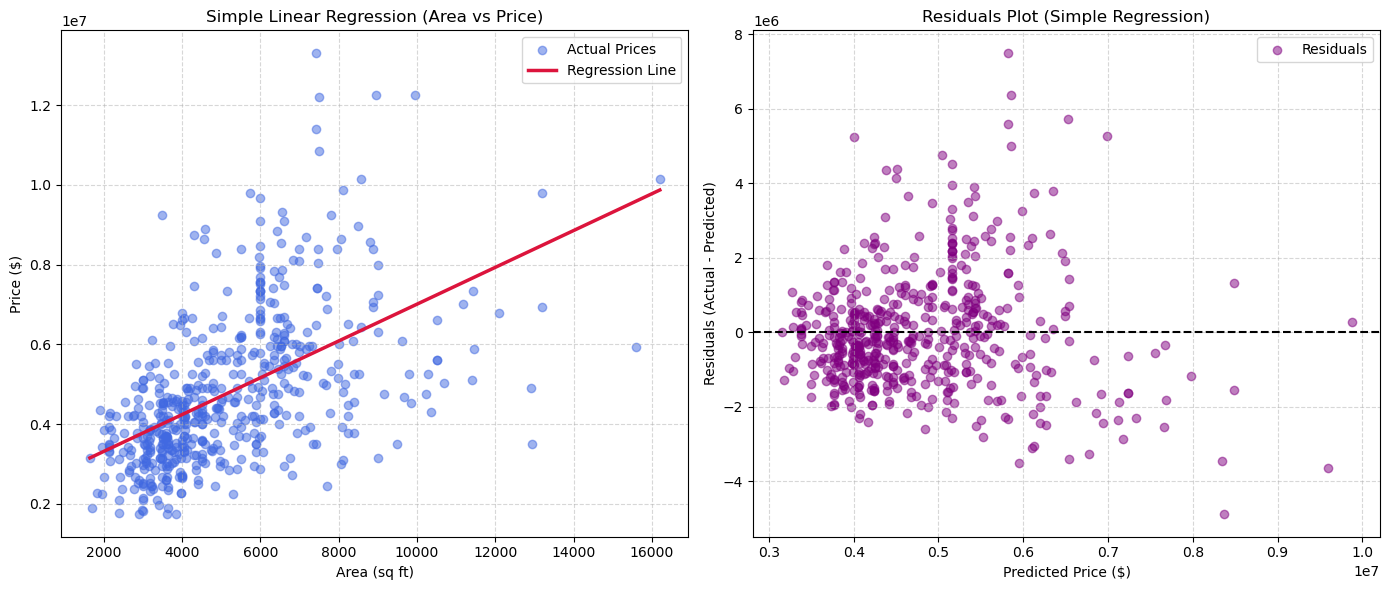

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load the Housing dataset
df = pd.read_csv(r"D:\Machine Learning Lab\Housing.csv")
y = df["price"].values

# ==========================================
# 2. Simple Linear Regression (Area vs Price)
# ==========================================
x_simple = df["area"].values
# Add intercept column of ones
X_sim = np.vstack([np.ones(len(x_simple)), x_simple]).T

# Compute parameters using Normal Equation
theta_sim = np.linalg.inv(X_sim.T @ X_sim) @ X_sim.T @ y
y_pred_sim = X_sim @ theta_sim

# Compute Metrics
rmse_sim = np.sqrt(np.mean((y - y_pred_sim) ** 2))
ss_total = np.sum((y - np.mean(y)) ** 2)
r2_sim = 1 - (np.sum((y - y_pred_sim) ** 2) / ss_total)

print("--- Simple Linear Regression Results ---")
print(f"Intercept: {theta_sim[0]:.2f} | Slope (Area): {theta_sim[1]:.2f}")
print(f"RMSE: {rmse_sim:.2f} | R²: {r2_sim:.4f}\n")


# ==========================================
# 3. Multiple Linear Regression
# ==========================================
features = ["area", "bedrooms", "bathrooms", "stories", "parking"]
X_mult_raw = df[features].values
# Add intercept column of ones
X_mult = np.hstack([np.ones((len(X_mult_raw), 1)), X_mult_raw])

# Compute parameters using Normal Equation
theta_mult = np.linalg.inv(X_mult.T @ X_mult) @ X_mult.T @ y
y_pred_mult = X_mult @ theta_mult

# Compute Metrics
rmse_mult = np.sqrt(np.mean((y - y_pred_mult) ** 2))
r2_mult = 1 - (np.sum((y - y_pred_mult) ** 2) / ss_total)

print("--- Multiple Linear Regression Results ---")
print(f"Intercept: {theta_mult[0]:.2f}")
for feat, coef in zip(features, theta_mult[1:]):
    print(f"Coefficient ({feat}): {coef:.2f}")
print(f"RMSE: {rmse_mult:.2f} | R²: {r2_mult:.4f}\n")


# ==========================================
# 4. Plotting Regression Line & Residuals
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Simple Linear Regression Line
axes[0].scatter(x_simple, y, color="royalblue", alpha=0.5, label="Actual Prices")
# Sort for a clean line plot
sorted_idx = np.argsort(x_simple)
axes[0].plot(
    x_simple[sorted_idx],
    y_pred_sim[sorted_idx],
    color="crimson",
    linewidth=2.5,
    label="Regression Line",
)
axes[0].set_title("Simple Linear Regression (Area vs Price)")
axes[0].set_xlabel("Area (sq ft)")
axes[0].set_ylabel("Price ($)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: Residuals Plot (Simple Regression)
residuals = y - y_pred_sim
axes[1].scatter(
    y_pred_sim, residuals, color="purple", alpha=0.5, label="Residuals"
)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals Plot (Simple Regression)")
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

--- Simple Linear Regression (Scikit-Learn) ---
Intercept: 2387308.48 | Slope: 461.97
RMSE: 1577612.56 | R²: 0.2873

--- Multiple Linear Regression (Scikit-Learn) ---
Intercept: -145734.49
Coefficient (area): 331.12
Coefficient (bedrooms): 167809.79
Coefficient (bathrooms): 1133740.16
Coefficient (stories): 547939.81
Coefficient (parking): 377596.29
RMSE: 1237339.31 | R²: 0.5616



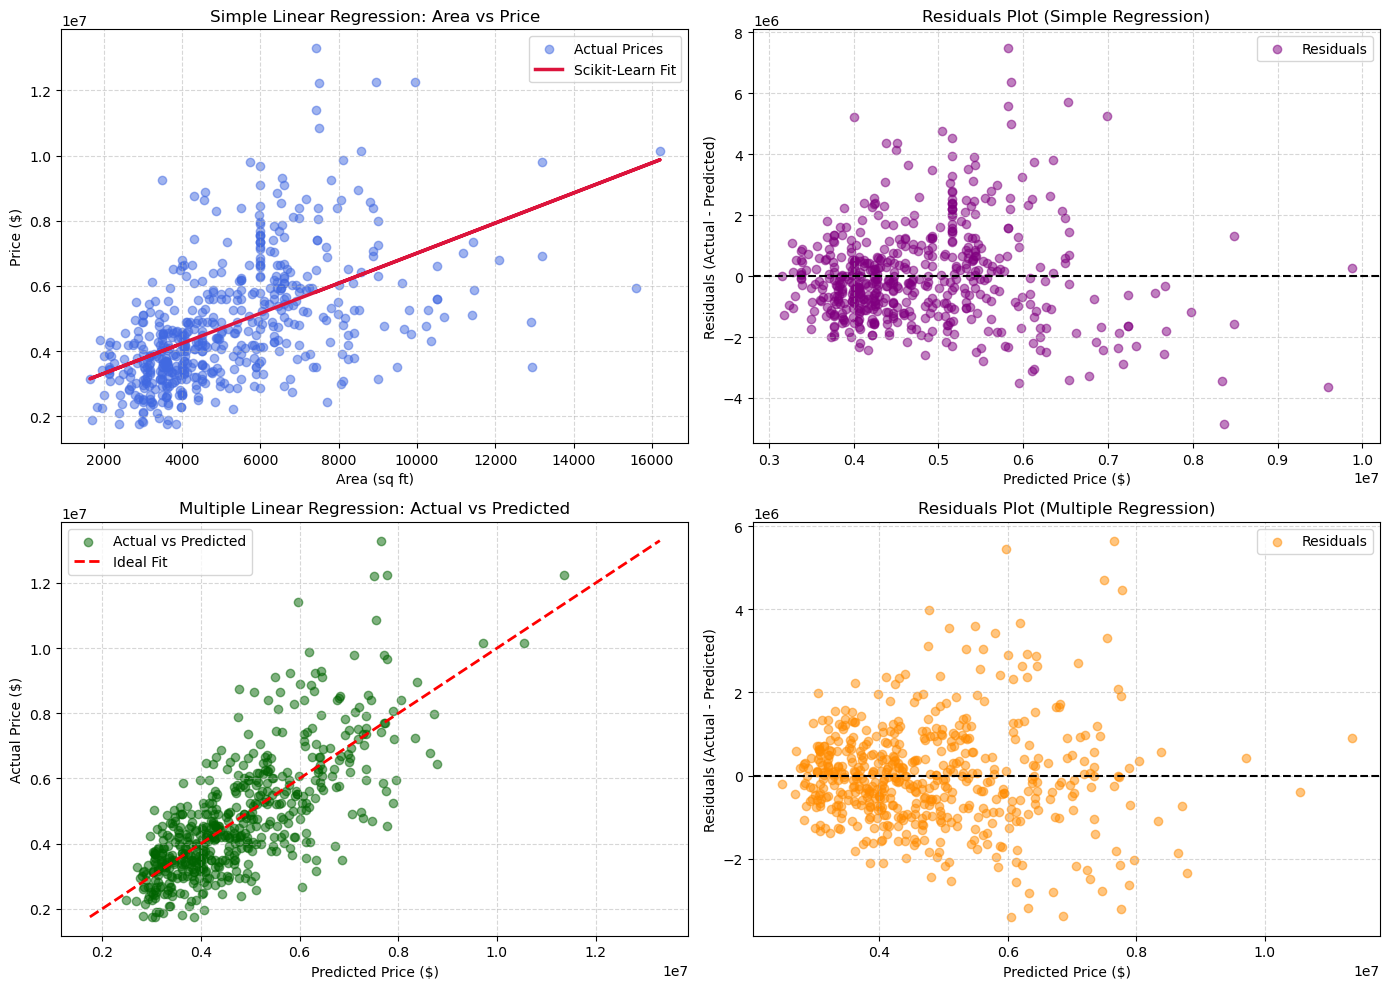

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the Housing dataset
df = pd.read_csv(r"D:\Machine Learning Lab\Housing.csv")
y = df["price"].values

# ==========================================
# 2. Simple Linear Regression (Area vs Price)
# ==========================================
X_simple = df[["area"]]  # 2D array for scikit-learn

lr_simple = LinearRegression()
lr_simple.fit(X_simple, y)
y_pred_simple = lr_simple.predict(X_simple)

# Metrics
rmse_simple = np.sqrt(mean_squared_error(y, y_pred_simple))
r2_simple = r2_score(y, y_pred_simple)

print("--- Simple Linear Regression (Scikit-Learn) ---")
print(f"Intercept: {lr_simple.intercept_:.2f} | Slope: {lr_simple.coef_[0]:.2f}")
print(f"RMSE: {rmse_simple:.2f} | R²: {r2_simple:.4f}\n")


# ==========================================
# 3. Multiple Linear Regression
# ==========================================
features = ["area", "bedrooms", "bathrooms", "stories", "parking"]
X_multi = df[features]

lr_multi = LinearRegression()
lr_multi.fit(X_multi, y)
y_pred_multi = lr_multi.predict(X_multi)

# Metrics
rmse_multi = np.sqrt(mean_squared_error(y, y_pred_multi))
r2_multi = r2_score(y, y_pred_multi)

print("--- Multiple Linear Regression (Scikit-Learn) ---")
print(f"Intercept: {lr_multi.intercept_:.2f}")
for feat, coef in zip(features, lr_multi.coef_):
    print(f"Coefficient ({feat}): {coef:.2f}")
print(f"RMSE: {rmse_multi:.2f} | R²: {r2_multi:.4f}\n")


# ==========================================
# 4. Plotting Regression Lines & Residuals
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Simple Linear Regression Fit
axes[0, 0].scatter(
    df["area"], y, color="royalblue", alpha=0.5, label="Actual Prices"
)
axes[0, 0].plot(
    df["area"],
    y_pred_simple,
    color="crimson",
    linewidth=2.5,
    label="Scikit-Learn Fit",
)
axes[0, 0].set_title("Simple Linear Regression: Area vs Price")
axes[0, 0].set_xlabel("Area (sq ft)")
axes[0, 0].set_ylabel("Price ($)")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: Residuals Plot for Simple Linear Regression
residuals_simple = y - y_pred_simple
axes[0, 1].scatter(
    y_pred_simple, residuals_simple, color="purple", alpha=0.5, label="Residuals"
)
axes[0, 1].axhline(y=0, color="black", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Residuals Plot (Simple Regression)")
axes[0, 1].set_xlabel("Predicted Price ($)")
axes[0, 1].set_ylabel("Residuals (Actual - Predicted)")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.5)

# Plot 3: Actual vs Predicted for Multiple Regression
axes[1, 0].scatter(
    y_pred_multi, y, color="darkgreen", alpha=0.5, label="Actual vs Predicted"
)
axes[1, 0].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ideal Fit",
)
axes[1, 0].set_title("Multiple Linear Regression: Actual vs Predicted")
axes[1, 0].set_xlabel("Predicted Price ($)")
axes[1, 0].set_ylabel("Actual Price ($)")
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# Plot 4: Residuals Plot for Multiple Linear Regression
residuals_multi = y - y_pred_multi
axes[1, 1].scatter(
    y_pred_multi, residuals_multi, color="darkorange", alpha=0.5, label="Residuals"
)
axes[1, 1].axhline(y=0, color="black", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Residuals Plot (Multiple Regression)")
axes[1, 1].set_xlabel("Predicted Price ($)")
axes[1, 1].set_ylabel("Residuals (Actual - Predicted)")
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

df = pd.read_csv("/Users/pratikvilasgadhe/Desktop/Programming/AI_ML/practical/Housing.csv")
# linear regression using scikit learn (direct method)
# area vs price
y_price = df['price'].values
x_area = df['area'].values

# Add intercept column of ones (b0)
x_sim = np.vstack([np.ones(len(x_area)),x_area]).T
print(x_sim)

[[1.00e+00 7.42e+03]
 [1.00e+00 8.96e+03]
 [1.00e+00 9.96e+03]
 ...
 [1.00e+00 3.62e+03]
 [1.00e+00 2.91e+03]
 [1.00e+00 3.85e+03]]
